## Multi-Scale CTG-Net

My Proposed Approach for the MS CTG-net:

** To address the single-scale receptive field limitation of the original CTG-Net architecture, a multi-scale convolutional neural network (MS-CNN) was proposed. While CTG-Net employs fixed-size temporal kernels, this design may fail to capture pathological patterns that manifest over longer temporal horizons, such as sustained baseline drift or prolonged decelerations. The proposed MS-CNN architecture incorporates parallel convolutional branches with varying temporal kernel sizes, enabling simultaneous extraction of fine-grained local patterns and broader contextual trends. Importantly, the model preserves the original CTG-Net signal processing pipeline, operating directly on raw CTG signals and maintaining identical training procedures, thereby ensuring a fair and controlled architectural comparison.

## Step 1: load the  Fetal Heart Rate (FHR) and Uterine Contradaction (UC) signals

This follows the CTG-net's preprocessing steps:

Classification: The 552 total samples were initially divided into 354 normal and 198 abnormal cases (according to pH and Apgar scores.)

Signal Cleaning: Repeated zero signals at the end of the samples were removed

Signal Extraction: The 30 minutes immediately preceding the last non-zero signals were extracted.

Selection: Only cases that satisfied the selection criteria (specifically, a signal loss less than 16%) were used for the final analysis, resulting in 52 normal and 26 abnormal cases.

In [2]:
# necessary imports
import pandas as pd 
from pathlib import Path
import wfdb
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, SeparableConv2D,
    BatchNormalization, Activation, AveragePooling2D,
    Dropout, Flatten, Dense, GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import KFold
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import resample
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

print("All necessary libraries imported successfully.")

All necessary libraries imported successfully.


In [3]:
# Add parent directory to path for imports
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

# Helper classes imports
from utils.datasetSampler import DatasetSampler
from utils.trainer import Trainer
from utils.evaluator import Evaluator
from utils.tenfoldCrossValidation import tenfoldCrossValidation
from utils.compileModel import compileModel
from utils.visualisation import generate_all_plots_and_tables, plot_probability_distributions, plot_precision_recall_curve_all, plot_roc_curves, plot_confusion_matrix

print("Helper classes imported successfully.")

Helper classes imported successfully.


In [4]:
# paths 
raw_dataset = Path("../data/raw_dataset")

records = [p.stem for p in raw_dataset.glob("*.hea")]
print(f"Found {len(records)} CTG records")



Found 552 CTG records


In [5]:
# Read one record to test
record = wfdb.rdrecord(raw_dataset / records[0])

signals = record.p_signal        
signal_names = record.sig_name   
fs = record.fs                  
print(f"Signal names: {signal_names}, Sampling rate: {fs} Hz")


Signal names: ['FHR', 'UC'], Sampling rate: 4 Hz


In [6]:
# Convert signals to a list
fhr = signals[:, 0].tolist()
uc = signals[:, 1].tolist()
print(f"First 10 FHR values: {fhr[:10]}")
print(f"First 10 UC values: {uc[:10]}")

First 10 FHR values: [150.5, 150.5, 151.0, 151.25, 151.25, 150.25, 150.25, 150.25, 148.75, 148.75]
First 10 UC values: [7.0, 8.5, 8.5, 7.5, 9.5, 8.5, 10.5, 12.0, 11.0, 11.5]


In [7]:
'''
Step 1: Classification 
CTG-net uses umblical arthery pH and Apgar scores:
Deliveries were classified as abnormal if the umbilical artery pH was lower than 7.20 or the Apgar score at 1 minute was lower than 7.
However, in my technique I use majority voting based on 9 obstetrician's assessment - as discussed before.
'''
# path to majority voting labels
Labels = '..\ExpertAnnotations\CTG_Majority_Vote_Labels_FINAL.csv'

# print number of normal and abnormal deliveries
labels_df = pd.read_csv(Labels)
num_normal = sum(labels_df['Clinical_Label'] == 'No Hypoxia (Normal)')
num_abnormal = sum(labels_df['Clinical_Label'] == 'Mild Hypoxia (Suspicious)')
print(f'Number of normal deliveries: {num_normal}')
print(f'Number of abnormal deliveries: {num_abnormal}')


Number of normal deliveries: 426
Number of abnormal deliveries: 126


In [8]:
'''
Step 2: Signal cleaning 
Repeated zero signals at the end of the samples were removed
'''
def remove_trailing_zeros(signal):
    """Remove trailing zeros from a signal."""
    if not isinstance(signal, list):
        raise ValueError("Input signal must be a list.")
    
    # Find the index of the last non-zero element
    last_non_zero_index = len(signal) - 1
    while last_non_zero_index >= 0 and signal[last_non_zero_index] == 0:
        last_non_zero_index -= 1
    
    # Return the signal up to the last non-zero element
    return signal[:last_non_zero_index + 1]

In [9]:
'''
Step 3: Signal Extraction
The 30 minutes immediately preceding the last non-zero signals were extracted.
'''
def extract_last_30_minutes(signal, sampling_rate=4):
    ''' reject short recordings and extract last 30 minutes of signal '''
    num_samples_30_minutes = 30 * 60 * sampling_rate

    if len(signal) < num_samples_30_minutes:
        return []  # reject short recordings

    return signal[-num_samples_30_minutes:]


In [10]:
'''
Step 4: Downsample signals to 1 Hz
The signals were originally sampled at 4 Hz. They were downsampled to 1 Hz by taking every fourth sample.
Paper explicitly states: “Signals were downsampled to 1 Hz for 30 minutes (1800 points)”
'''
def downsample_to_1hz(signal, original_fs=4, target_fs=1):
    factor = original_fs // target_fs
    return signal[::factor]


In [11]:
'''
Step 5: Selection
Only cases that satisfied the selection criteria (specifically, a signal loss less than 16%) were used for the final analysis
'''
def is_signal_acceptable(signal, threshold=0.16):
    """Check if the signal loss is within the acceptable threshold."""
    
    # Reject empty or invalid signals
    if not signal or len(signal) == 0:
        return False
    
    total_length = len(signal)
    zero_count = signal.count(0)
    signal_loss = zero_count / total_length
    
    return signal_loss < threshold


In [12]:
''' 
Step 6: Perform the above steps on the dataset 
'''
processed_records = []

for rec in records:
    record = wfdb.rdrecord(raw_dataset / rec)
    signals = record.p_signal

    fhr = signals[:, 0].tolist()
    uc  = signals[:, 1].tolist()

    # Cleaning 
    fhr = remove_trailing_zeros(fhr)
    uc  = remove_trailing_zeros(uc)

    # Extraction 
    fhr = extract_last_30_minutes(fhr, sampling_rate=record.fs)
    uc  = extract_last_30_minutes(uc, sampling_rate=record.fs)

    # Downsampling
    fhr = downsample_to_1hz(fhr, original_fs=fs, target_fs=1)
    uc  = downsample_to_1hz(uc, original_fs=fs, target_fs=1)

    # Selection
    if is_signal_acceptable(fhr) and is_signal_acceptable(uc):
        processed_records.append({
            "rec_id": rec,
            "FHR": fhr,
            "UC": uc
        })


In [13]:
data_df = pd.DataFrame(processed_records)
print(data_df.shape)


(220, 3)


In [14]:
labels_df = pd.read_csv(Labels)
print(labels_df.columns)
data_df['rec_id'] = data_df['rec_id'].astype(str)
labels_df['rec_id'] = labels_df['rec_id'].astype(str)
merged_df = data_df.merge(
    labels_df,
    left_on="rec_id",
    right_on="rec_id",
    how="inner"
)

print(merged_df.shape)
label_counts = merged_df['Clinical_Label'].value_counts()
print(label_counts)




Index(['rec_id', 'Majority_Vote_Label', 'Clinical_Label'], dtype='object')
(220, 5)
Clinical_Label
No Hypoxia (Normal)          164
Mild Hypoxia (Suspicious)     56
Name: count, dtype: int64


In [15]:
def normalize_signals(X):
    """
    Normalize FHR and UC signals independently per sample
    Paper likely used z-score normalization
    """
    X_norm = np.zeros_like(X, dtype=np.float32)
    
    for i in range(len(X)):
        # Normalize FHR (channel 0)
        fhr = X[i, 0, :, 0]
        fhr_mean = np.mean(fhr)
        fhr_std = np.std(fhr)
        if fhr_std > 0:
            X_norm[i, 0, :, 0] = (fhr - fhr_mean) / fhr_std
        else:
            X_norm[i, 0, :, 0] = fhr - fhr_mean
        
        # Normalize UC (channel 1)
        uc = X[i, 1, :, 0]
        uc_mean = np.mean(uc)
        uc_std = np.std(uc)
        if uc_std > 0:
            X_norm[i, 1, :, 0] = (uc - uc_mean) / uc_std
        else:
            X_norm[i, 1, :, 0] = uc - uc_mean
    
    return X_norm

## Building a 2D Multi-Scale Kernel Convolutional Neural Network (MS-CNN) 

In [16]:
''' 
Step 1: Change labels from binary (normal, abnormal) to one- hot encoding
'''

# Label encoding
X = np.array([
    np.stack([row["FHR"], row["UC"]], axis=0)
    for _, row in merged_df.iterrows()
])[..., np.newaxis]

# Labels → one-hot encoding
le = LabelEncoder()
y_int = le.fit_transform(merged_df["Clinical_Label"])  # 0 = abnormal, 1= normal
y = to_categorical(y_int, num_classes=2)



In [17]:
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, SeparableConv2D,
    BatchNormalization, Activation, AveragePooling2D,
    Dropout, GlobalAveragePooling2D, Dense, Concatenate
)
from tensorflow.keras.models import Model


def build_ctg_ms_cnn(input_shape=(2, 1800, 1), dropout_rate=0.25):
    inputs = Input(shape=input_shape)

    # --- Stage 1: Temporal filtering (same as CTG-Net) ---
    x = Conv2D(filters=4, kernel_size=(1, 3), padding="same", use_bias=False)(inputs)
    x = BatchNormalization()(x)

    # --- Stage 2: Signal interaction (same as CTG-Net) ---
    x = DepthwiseConv2D(kernel_size=(2, 1), depth_multiplier=2, use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    # --- Pooling ---
    x = AveragePooling2D(pool_size=(1, 4))(x)
    x = Dropout(dropout_rate)(x)

    # --- Stage 3: Multi-Scale Temporal Feature Extraction ---
    branch_small = SeparableConv2D(filters=8, kernel_size=(1, 3),
                                   padding="same", use_bias=False)(x)
    branch_small = BatchNormalization()(branch_small)
    branch_small = Activation("relu")(branch_small)

    branch_medium = SeparableConv2D(filters=8, kernel_size=(1, 7),
                                    padding="same", use_bias=False)(x)
    branch_medium = BatchNormalization()(branch_medium)
    branch_medium = Activation("relu")(branch_medium)

    branch_large = SeparableConv2D(filters=8, kernel_size=(1, 15),
                                   padding="same", use_bias=False)(x)
    branch_large = BatchNormalization()(branch_large)
    branch_large = Activation("relu")(branch_large)

    # --- Concatenate multi-scale features ---
    x = Concatenate(axis=-1)([branch_small, branch_medium, branch_large])  # (1, T, 24)

    # --- Channel projection (keeps parameter count reasonable) ---
    x = Conv2D(filters=8, kernel_size=(1, 1), use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    # --- Pooling ---
    x = AveragePooling2D(pool_size=(1, 4))(x)
    x = Dropout(dropout_rate)(x)

    # --- Classification head (same as your personalised CTG-Net) ---
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(2, activation="softmax")(x)

    model = Model(inputs, outputs, name="CTG-MS-CNN")
    return model


In [18]:
model = build_ctg_ms_cnn()
model.summary()

Model: "CTG-MS-CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2, 1800,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 2, 1800,   │         12 │ input_layer[0][0] │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2, 1800,   │         16 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 1, 1800,   │         16 │ batch_normalizat… │
│ (DepthwiseConv2D)   │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 1800,   │         32 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1, 1800,   │          0 │ batch_normalizat… │
│ (Activation)        │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 1, 450, 8) │          0 │ activation[0][0]  │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1, 450, 8) │          0 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 1, 450, 8) │         88 │ dropout[0][0]     │
│ (SeparableConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 1, 450, 8) │        120 │ dropout[0][0]     │
│ (SeparableConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 1, 450, 8) │        184 │ dropout[0][0]     │
│ (SeparableConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 450, 8) │         32 │ separable_conv2d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 450, 8) │         32 │ separable_conv2d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 450, 8) │         32 │ separable_conv2d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 1, 450, 8) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 1, 450, 8) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 1, 450, 8) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                 

 Total params: 806 (3.15 KB)

 Trainable params: 718 (2.80 KB)

 Non-trainable params: 88 (352.00 B)

In [19]:
# Compile the model in a fixed way
model = compileModel(model)


In [20]:
sampler = DatasetSampler(normal_label=1, abnormal_label=0)
trainer = Trainer(batch_size=8, max_epochs=300)
evaluator = Evaluator(thresholds=[0.2, 0.3, 0.4, 0.5])

experiment = tenfoldCrossValidation(
    model_fn = build_ctg_ms_cnn,
    sampler=sampler,
    trainer=trainer,
    evaluator=evaluator,
    n_iterations=10,
    n_splits=10
)

In [21]:
# Setup reusable utilities
trainer = Trainer(batch_size=8, max_epochs=300)
sampler = DatasetSampler()
evaluator = Evaluator([0.2, 0.3, 0.4, 0.5])


In [22]:
# Run tenfold cross-validation
experiment = tenfoldCrossValidation(
    model_fn=lambda: compileModel(build_ctg_ms_cnn()),  # returns a freshly compiled model each fold
    sampler=sampler,
    trainer=trainer,
    evaluator=evaluator
)

In [23]:
results = experiment.run(X, y, y_int, normalize_signals)


Iteration 1/10

--- Fold 1/10 ---
Train: Normal=50, Abnormal=50, Total=100
Test:  Normal=6, Abnormal=6, Total=12
Class weights: 0=1.00, 1=1.00
Training... 
Epoch 130: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 181: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 191: early stopping
Restoring model weights from the end of the best epoch: 166.
Done! (191 epochs, final loss=0.4013)
Predictions: min=0.107, max=0.914, mean=0.588, std=0.244
AUC: 0.556
Thr: 0.200 | F1: 0.706 | Prec: 0.545 | Rec: 1.000 | Sens: 1.000 | Acc: 0.583
Thr: 0.300 | F1: 0.625 | Prec: 0.500 | Rec: 0.833 | Sens: 0.833 | Acc: 0.500
Thr: 0.400 | F1: 0.533 | Prec: 0.444 | Rec: 0.667 | Sens: 0.667 | Acc: 0.417
Thr: 0.500 | F1: 0.615 | Prec: 0.571 | Rec: 0.667 | Sens: 0.667 | Acc: 0.583

--- Fold 2/10 ---
Train: Normal=50, Abnormal=50, Total=100
Test:  Normal=6, Abnormal=6, Total=12
Class weights: 0=1.00, 1=1.00
Training... 
Epoch 15: ReduceLROnPlateau reducing learnin

In [87]:
# diagnostic — run after `results = experiment.run(...)`
import numpy as np
aucs = [r.get("auc", np.nan) for r in results]
aucs = np.array(aucs, dtype=float)
print("n_folds:", len(aucs))
print("nan indices:", np.where(np.isnan(aucs))[0].tolist())
print("aucs min/max/mean (ignoring NaN):", np.nanmin(aucs), np.nanmax(aucs), np.nanmean(aucs))
# inspect problematic fold(s)
for i in np.where(np.isnan(aucs))[0]:
    fr = results[i]
    print("fold", i, "has auc nan; y_true unique:", np.unique(fr.get("y_true")))
    print("y_prob stats:", np.nanmin(fr.get("y_prob")), np.nanmax(fr.get("y_prob")), "nan_count:", np.sum(np.isnan(fr.get("y_prob"))))

n_folds: 100
nan indices: [22, 66]
aucs min/max/mean (ignoring NaN): 0.04166666666666667 0.9 0.4300722850467748
fold 22 has auc nan; y_true unique: [1.]
y_prob stats: 0.4022527 0.60280204 nan_count: 0
fold 66 has auc nan; y_true unique: [1.]
y_prob stats: 0.048155114 0.7011438 nan_count: 0


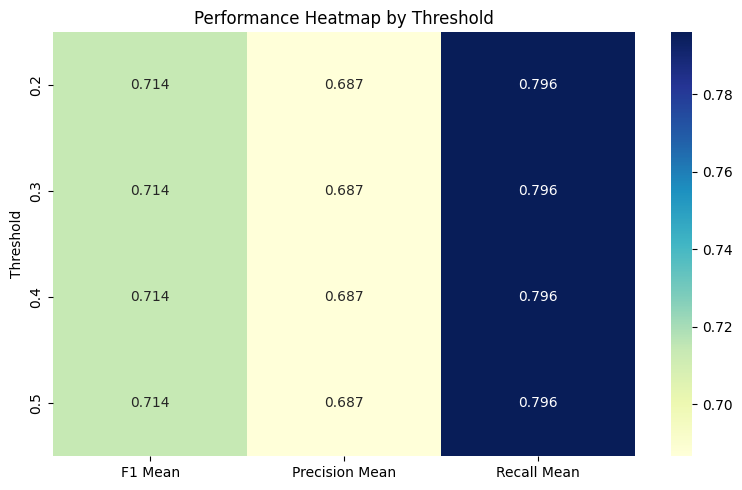

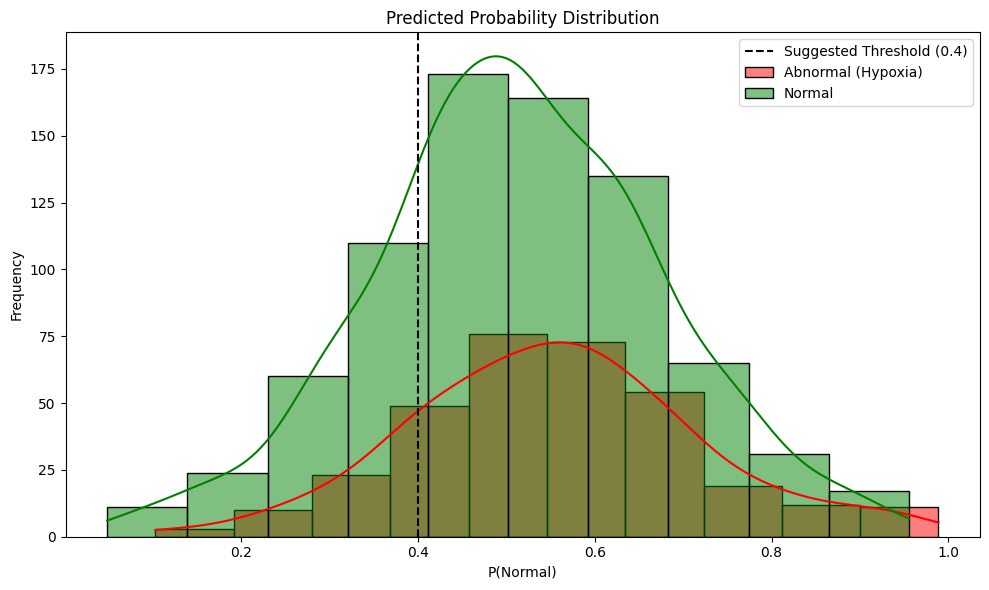

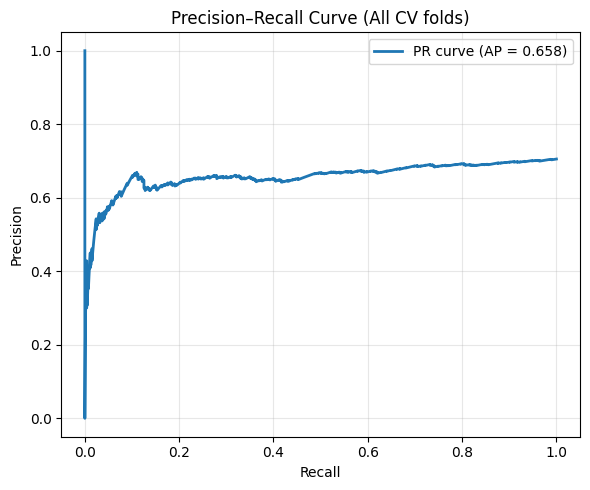

c:\Users\ZEYNEP\OneDrive\Desktop\CTG_Dissertation\venv\Lib\site-packages\sklearn\metrics\_ranking.py:1294: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
c:\Users\ZEYNEP\OneDrive\Desktop\CTG_Dissertation\venv\Lib\site-packages\sklearn\metrics\_ranking.py:1294: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


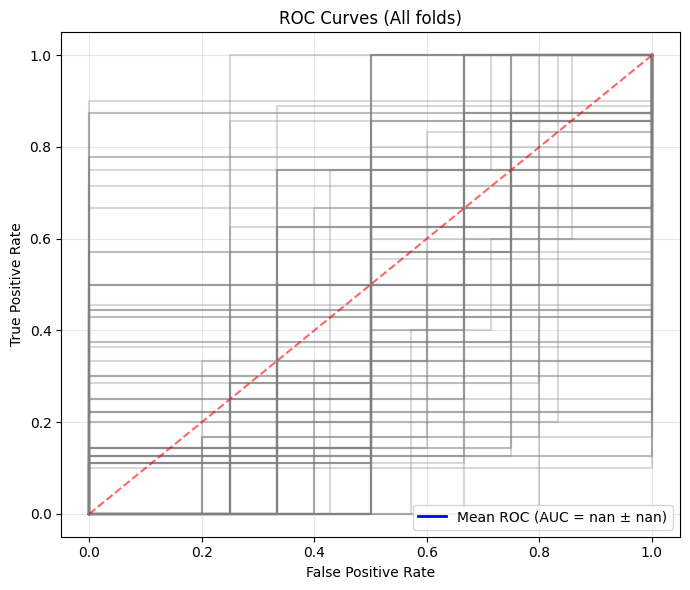

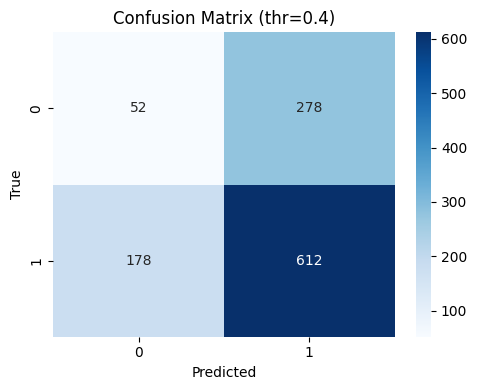

{'threshold_metrics':             F1 Mean    F1 Std  Precision Mean  Precision Std  Recall Mean  \
Threshold                                                                   
0.2        0.714093  0.175046        0.686553       0.159384     0.796027   
0.3        0.714093  0.175046        0.686553       0.159384     0.796027   
0.4        0.714093  0.175046        0.686553       0.159384     0.796027   
0.5        0.714093  0.175046        0.686553       0.159384     0.796027   

           Recall Std  
Threshold              
0.2          0.243969  
0.3          0.243969  
0.4          0.243969  
0.5          0.243969  , 'ap': 0.6580499516219103, 'mean_auc': nan, 'std_auc': nan, 'confusion_matrix': array([[ 52, 278],
       [178, 612]], dtype=int64), 'figure_dir': WindowsPath('outputs/figures/MS-CNN')}


In [83]:
# reload and call (run this cell)
import sys
import importlib
if 'utils.visualisation' in sys.modules:
    del sys.modules['utils.visualisation']
from utils.visualisation import generate_all_plots_and_tables, plot_probability_distributions, plot_precision_recall_curve_all, plot_roc_curves, plot_confusion_matrix
from pathlib import Path
save_dir = Path("outputs/figures/MS-CNN")
save_dir.mkdir(parents=True, exist_ok=True)

# ensure y_prob is probability for the positive class (Normal). If you have softmax outputs use:
# y_prob = np.array([p[1] for p in y_prob_raw]) 
# prepare fold lists: y_true_folds = [...], y_prob_folds = [...]
res = generate_all_plots_and_tables(
    thresholds, f1_scores, precision_scores, recall_scores,
    y_prob, y_test_int, y_true_folds, y_prob_folds,
    model_name="MS-CNN", suggested_threshold=0.4,
    save_tables=True, save_path="outputs/tables/ms_cnn_threshold_metrics.csv", show=True
)
print(res)